In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [83]:
df=pd.read_csv('medical_Diagnosis_dataset.csv')
df

,glucose_level,blood_pressure,cholesterol,bmi,age,feature_6,feature_7,feature_8,feature_9,feature_10,target,smoking_status
0,-1.030931,1.391626,0.547274,0.928932,-1.738880,1.250002,1.332551,1.578256,2.124722,-0.318434,0,Former
1,-1.930636,-0.406752,3.061308,1.083145,-2.934634,-1.355054,-1.794192,-0.873019,7.065968,2.110308,0,Smoker
2,-0.558987,0.299849,1.527071,0.360442,-1.360209,1.100793,-0.755951,1.331933,2.041105,-0.824404,0,Non-smoker
3,-1.350289,-2.046078,-0.614264,0.126459,-0.783923,5.895026,-0.915477,-3.184768,-0.399260,-3.920960,0,Non-smoker
4,-0.275754,-0.728495,0.027727,-0.660834,-1.928161,3.544945,1.446944,-1.111662,0.313766,-2.376528,0,Non-smoker
...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.326662,0.667346,-1.258075,-1.075737,-1.266081,1.746493,-0.528998,-2.528915,-0.244415,-1.203668,0,Former
996,0.075206,0.198699,1.878295,-1.007868,-1.424495,-1.149712,-0.608494,1.537761,2.524093,0.864625,0,Smoker
997,-2.728454,-0.352948,1.461926,1.127686,-3.808356,6.246633,0.958816,0.233868,4.350736,-3.104087,0,Non-smoker
998,-0.987192,1.676627,-0.235451,-0.006647,-0.408889,1.080665,-0.157025,2.201371,-0.727689,-1.082463,0,Former


In [84]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   glucose_level   1000 non-null   float64
 1   blood_pressure  1000 non-null   float64
 2   cholesterol     1000 non-null   float64
 3   bmi             1000 non-null   float64
 4   age             1000 non-null   float64
 5   feature_6       1000 non-null   float64
 6   feature_7       1000 non-null   float64
 7   feature_8       1000 non-null   float64
 8   feature_9       1000 non-null   float64
 9   feature_10      1000 non-null   float64
 10  target          1000 non-null   int64  
 11  smoking_status  1000 non-null   object 
dtypes: float64(10), int64(1), object(1)
memory usage: 93.9+ KB


In [85]:
df.describe()

,glucose_level,blood_pressure,cholesterol,bmi,age,feature_6,feature_7,feature_8,feature_9,feature_10,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.987192,0.049559,-0.048558,-0.006647,-0.760523,1.876671,-0.024828,0.034693,0.926480,-0.760954,0.106000
std,0.945743,1.541166,1.711178,0.966008,1.769060,2.217174,1.052177,1.821284,2.070509,1.681686,0.307992
min,-4.247963,-5.446468,-5.558615,-3.688365,-7.844223,-5.639699,-3.221016,-6.274085,-5.495407,-6.626081,0.000000
25%,-1.586288,-0.941598,-1.259443,-0.608662,-2.043784,0.385351,-0.737644,-1.176866,-0.445276,-1.850878,0.000000
50%,-0.987192,0.106014,0.033210,-0.006647,-0.734590,2.047293,-0.060376,0.108569,0.708714,-0.743577,0.000000
75%,-0.432312,1.066150,1.194692,0.603761,0.436495,3.477828,0.730339,1.252404,2.174464,0.357380,0.000000
max,2.695232,4.604960,4.584841,3.529055,5.466089,8.254264,2.943048,5.066045,8.263826,5.379806,1.000000


In [86]:
df.isnull().sum()

glucose_level     0
blood_pressure    0
cholesterol       0
bmi               0
age               0
feature_6         0
feature_7         0
feature_8         0
feature_9         0
feature_10        0
target            0
smoking_status    0
dtype: int64

<Figure size 1000x600 with 0 Axes>

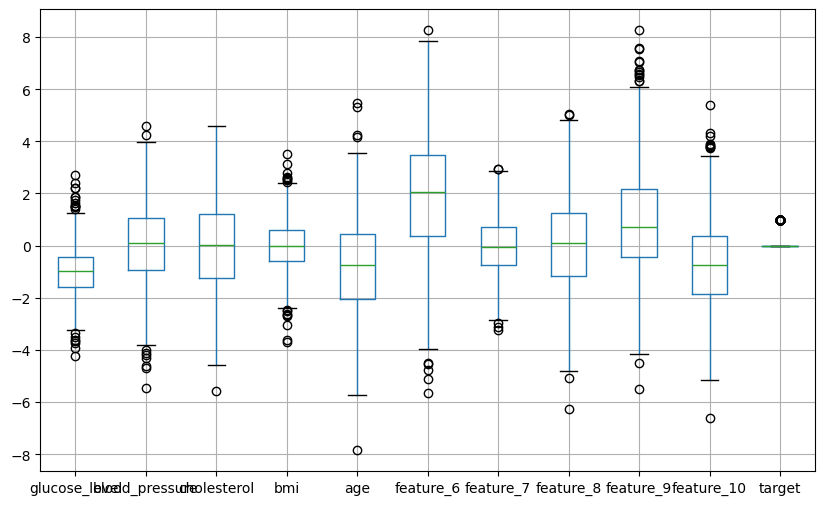

In [87]:
df.boxplot()
plt.show()

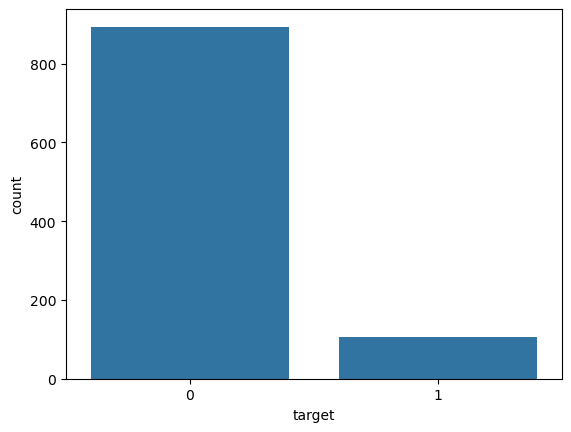

In [88]:
sns.countplot(x='target',data=df)
plt.show()

In [89]:
#convrt to realistic age 
df['age']=(df['age']-df['age'].min())/(df['age'].max()-df['age'].min())
# in range between 18 and 80
df['age']=df['age']*(80-18)+18
df['age']=df['age'].astype(int)
df['age'].head()

0    46
1    40
2    48
3    50
4    45
Name: age, dtype: int32

In [90]:
# one hot encoding for smoking status
df=pd.get_dummies(df)
df

,glucose_level,blood_pressure,cholesterol,bmi,age,feature_6,feature_7,feature_8,feature_9,feature_10,target,smoking_status_Former,smoking_status_Non-smoker,smoking_status_Smoker
0,-1.030931,1.391626,0.547274,0.928932,46,1.250002,1.332551,1.578256,2.124722,-0.318434,0,True,False,False
1,-1.930636,-0.406752,3.061308,1.083145,40,-1.355054,-1.794192,-0.873019,7.065968,2.110308,0,False,False,True
2,-0.558987,0.299849,1.527071,0.360442,48,1.100793,-0.755951,1.331933,2.041105,-0.824404,0,False,True,False
3,-1.350289,-2.046078,-0.614264,0.126459,50,5.895026,-0.915477,-3.184768,-0.399260,-3.920960,0,False,True,False
4,-0.275754,-0.728495,0.027727,-0.660834,45,3.544945,1.446944,-1.111662,0.313766,-2.376528,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.326662,0.667346,-1.258075,-1.075737,48,1.746493,-0.528998,-2.528915,-0.244415,-1.203668,0,True,False,False
996,0.075206,0.198699,1.878295,-1.007868,47,-1.149712,-0.608494,1.537761,2.524093,0.864625,0,False,False,True
997,-2.728454,-0.352948,1.461926,1.127686,36,6.246633,0.958816,0.233868,4.350736,-3.104087,0,False,True,False
998,-0.987192,1.676627,-0.235451,-0.006647,52,1.080665,-0.157025,2.201371,-0.727689,-1.082463,0,True,False,False


In [91]:

df['smoking_status_Former']=df['smoking_status_Former'].replace({False:0,True:1})
df['smoking_status_Non-smoker']=df['smoking_status_Non-smoker'].replace({False:0,True:1})
df['smoking_status_Smoker']=df['smoking_status_Smoker'].replace({False:0,True:1})
df.head()

C:\Users\ram\AppData\Local\Temp\ipykernel_5436\1791948668.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['smoking_status_Former']=df['smoking_status_Former'].replace({False:0,True:1})
C:\Users\ram\AppData\Local\Temp\ipykernel_5436\1791948668.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['smoking_status_Non-smoker']=df['smoking_status_Non-smoker'].replace({False:0,True:1})
C:\Users\ram\AppData\Local\Temp\ipykernel_5436\1791948668.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be remov

,glucose_level,blood_pressure,cholesterol,bmi,age,feature_6,feature_7,feature_8,feature_9,feature_10,target,smoking_status_Former,smoking_status_Non-smoker,smoking_status_Smoker
0,-1.030931,1.391626,0.547274,0.928932,46,1.250002,1.332551,1.578256,2.124722,-0.318434,0,1,0,0
1,-1.930636,-0.406752,3.061308,1.083145,40,-1.355054,-1.794192,-0.873019,7.065968,2.110308,0,0,0,1
2,-0.558987,0.299849,1.527071,0.360442,48,1.100793,-0.755951,1.331933,2.041105,-0.824404,0,0,1,0
3,-1.350289,-2.046078,-0.614264,0.126459,50,5.895026,-0.915477,-3.184768,-0.399260,-3.920960,0,0,1,0
4,-0.275754,-0.728495,0.027727,-0.660834,45,3.544945,1.446944,-1.111662,0.313766,-2.376528,0,0,1,0


In [92]:
# clip the outliers
for column in df.columns:
    if column != 'target':
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
        df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

In [93]:
df['target'].value_counts()

target
0    894
1    106
Name: count, dtype: int64

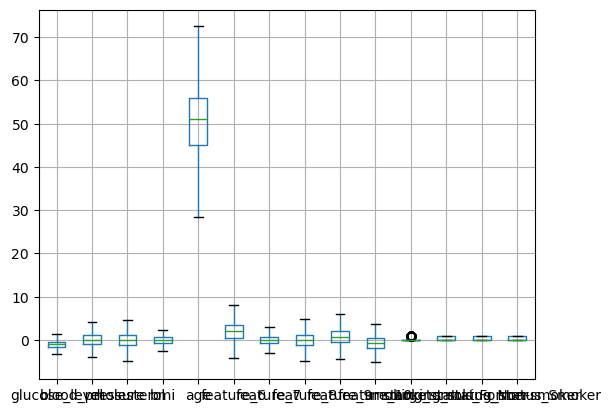

In [94]:
df.boxplot()
plt.show()

In [95]:
#sns.pairplot(df)
#plt.show()

In [96]:
#hendeling the imbalanced data of target col using sampling
from imblearn.over_sampling import SMOTE


In [97]:
X=df.drop('target',axis=1)
y=df['target']

In [98]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

smote=SMOTE(random_state=42)
X_train_res,y_train_res=smote.fit_resample(X_train,y_train)

In [99]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score


In [100]:
#model without fearure scaling
from sklearn.svm import SVC
model=SVC(kernel='rbf',random_state=42)
y_pred=model.fit(X_train_res,y_train_res).predict(X_test)

print('Accuracy:', accuracy_score(y_test,y_pred))
print('Classification Report:')
print(classification_report(y_test,y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test,y_pred))


Accuracy: 0.705
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.68      0.81       179
           1       0.25      0.90      0.39        21

    accuracy                           0.70       200
   macro avg       0.62      0.79      0.60       200
weighted avg       0.91      0.70      0.76       200

Confusion Matrix:
[[122  57]
 [  2  19]]


In [103]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
x_train_pca = pca.fit_transform(X_train)
x_test_pca = pca.transform(X_test)

In [106]:
model_pca = SVC(kernel='rbf', random_state=42)
model_pca.fit(x_train_pca, y_train)

SVC(random_state=42)

<Figure size 1000x600 with 0 Axes>

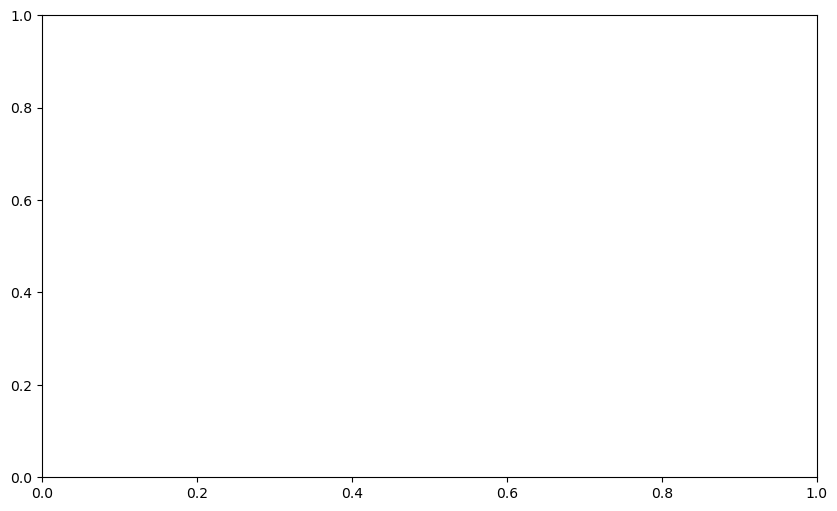

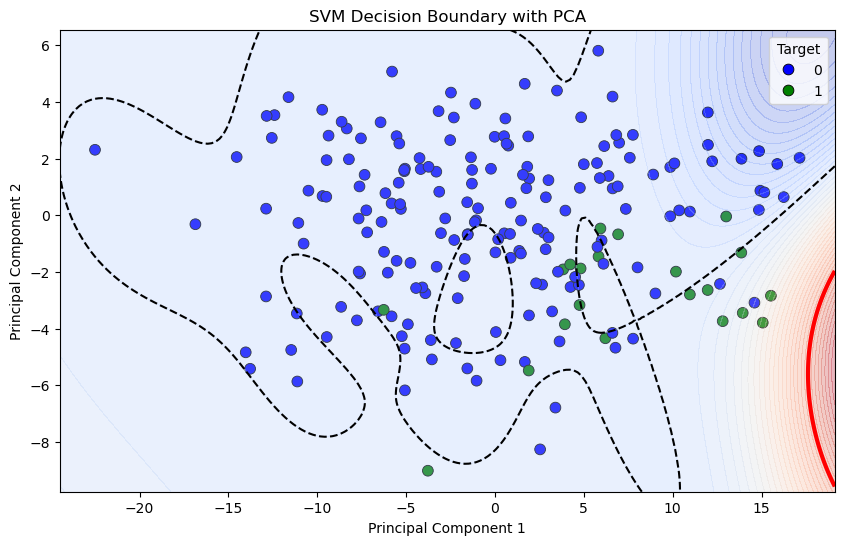

In [109]:

 
plt.figure(figsize=(10, 6))
 
#  Plot points (custom colors)
sns.scatterplot(
    x=x_test_pca[:, 0],
    y=x_test_pca[:, 1],
    hue=y_test,
    palette={0: "blue", 1: "green"},  # custom colors
    edgecolor="black",
    s=60
)
 
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
 
# mesh grid
xx, yy = np.meshgrid(
    np.linspace(xlim[0], xlim[1], 200),
    np.linspace(ylim[0], ylim[1], 200)
)
 
# decision function
Z = model_pca.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
 
plt.contourf(xx, yy, Z, levels=50, cmap="coolwarm", alpha=0.3)
 
#  DARK boundary line (IMPORTANT)
plt.contour(
    xx, yy, Z,
    levels=[0],            # decision boundary
    colors='red',
    linewidths=3
)
 
# optional: margins (SVM support margin lines)
plt.contour(
    xx, yy, Z,
    levels=[-1, 1],
    colors='black',
    linestyles='dashed',
    linewidths=1.5
)
 
plt.title('SVM Decision Boundary with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Target')
 
plt.show()